## Applying K-Means Clustering on Personal Performance Features

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

from src.visualization.plots import show_correlation_matrix
from src.data.calculations import calculate_correlation_matrix

In [2]:
data = pd.read_csv('../../data/processed/personal_performance_data.csv')
data

,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,freekick_accuracy,long_passing,ball_control,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,86,95,70,92,86,97,93,94,89,96,...,94,48,22,94,94,75,96,33,28,26
1,88,81,52,91,80,84,86,87,89,91,...,89,46,56,84,91,67,88,59,57,22
2,80,75,75,86,85,87,85,82,90,90,...,82,78,64,82,88,82,87,63,67,67
3,86,77,56,85,74,90,87,77,78,93,...,84,34,26,83,87,61,83,51,24,22
4,30,22,83,68,14,69,28,28,60,63,...,15,87,88,24,49,33,80,91,88,87
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,57,61,60,66,37,64,53,47,61,66,...,54,69,41,60,64,63,56,40,20,18
17950,50,19,53,55,31,52,26,28,43,53,...,22,62,55,42,39,32,52,53,64,60
17951,11,9,13,26,9,12,13,12,24,18,...,9,27,10,5,25,16,47,9,12,13
17952,42,60,55,49,49,57,47,39,37,56,...,58,38,15,54,52,50,53,16,18,17


In [3]:
data.shape

(17954, 29)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   crossing           17954 non-null  int64
 1   finishing          17954 non-null  int64
 2   heading_accuracy   17954 non-null  int64
 3   short_passing      17954 non-null  int64
 4   volleys            17954 non-null  int64
 5   dribbling          17954 non-null  int64
 6   curve              17954 non-null  int64
 7   freekick_accuracy  17954 non-null  int64
 8   long_passing       17954 non-null  int64
 9   ball_control       17954 non-null  int64
 10  acceleration       17954 non-null  int64
 11  sprint_speed       17954 non-null  int64
 12  agility            17954 non-null  int64
 13  reactions          17954 non-null  int64
 14  balance            17954 non-null  int64
 15  shot_power         17954 non-null  int64
 16  jumping            17954 non-null  int64
 17  stamina     

In [5]:
data.isna().sum()

crossing             0
finishing            0
heading_accuracy     0
short_passing        0
volleys              0
dribbling            0
curve                0
freekick_accuracy    0
long_passing         0
ball_control         0
acceleration         0
sprint_speed         0
agility              0
reactions            0
balance              0
shot_power           0
jumping              0
stamina              0
strength             0
long_shots           0
aggression           0
interceptions        0
positioning          0
vision               0
penalties            0
composure            0
marking              0
standing_tackle      0
sliding_tackle       0
dtype: int64

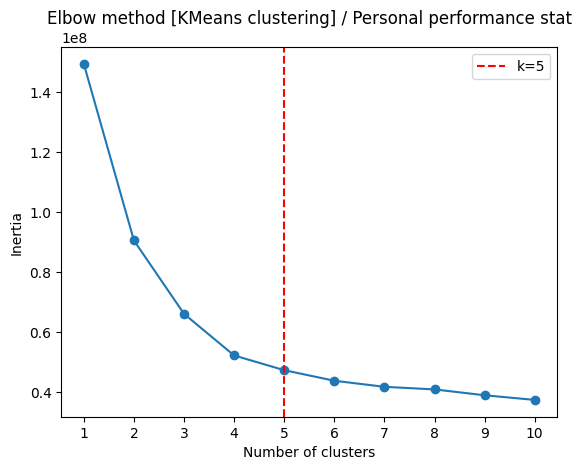

In [6]:
# Create an empty list where the inertia values for each K-Means model will be stored.
inertias = []

# Test different numbers of clusters from 1 to 10.
for i in range(1, 11):
    km = KMeans(n_clusters=i)
    km.fit(data)

    # Store the inertia value for the current number of clusters.
    # Inertia measures how close the data points are to their assigned cluster centers.
    inertias.append(km.inertia_)

# Plot the inertia values for each number of clusters.
# This helps us visually apply the Elbow Method.
plt.plot(range(1, 11), inertias, marker='o')


plt.title('Elbow method [KMeans clustering] / Personal performance stat')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(range(1, 11))

plt.axvline(x=5, linestyle='--', label='k=5', c='r')

plt.legend()
plt.show()

In [7]:
model = KMeans(n_clusters=5, random_state=42)
model.fit(data)

,n_clusters,5
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [8]:
# Fit the model and assign each player to a cluster.
data['pp_cluster'] = model.fit_predict(data)

In [9]:
data

,crossing,finishing,heading_accuracy,short_passing,volleys,dribbling,curve,freekick_accuracy,long_passing,ball_control,...,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle,pp_cluster
0,86,95,70,92,86,97,93,94,89,96,...,48,22,94,94,75,96,33,28,26,4
1,88,81,52,91,80,84,86,87,89,91,...,46,56,84,91,67,88,59,57,22,4
2,80,75,75,86,85,87,85,82,90,90,...,78,64,82,88,82,87,63,67,67,1
3,86,77,56,85,74,90,87,77,78,93,...,34,26,83,87,61,83,51,24,22,4
4,30,22,83,68,14,69,28,28,60,63,...,87,88,24,49,33,80,91,88,87,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17949,57,61,60,66,37,64,53,47,61,66,...,69,41,60,64,63,56,40,20,18,4
17950,50,19,53,55,31,52,26,28,43,53,...,62,55,42,39,32,52,53,64,60,0
17951,11,9,13,26,9,12,13,12,24,18,...,27,10,5,25,16,47,9,12,13,2
17952,42,60,55,49,49,57,47,39,37,56,...,38,15,54,52,50,53,16,18,17,3


In [10]:
cluster_0 = data[data['pp_cluster'] == 0]
cluster_1 = data[data['pp_cluster'] == 1]
cluster_2 = data[data['pp_cluster'] == 2]
cluster_3 = data[data['pp_cluster'] == 3]
cluster_4 = data[data['pp_cluster'] == 4]

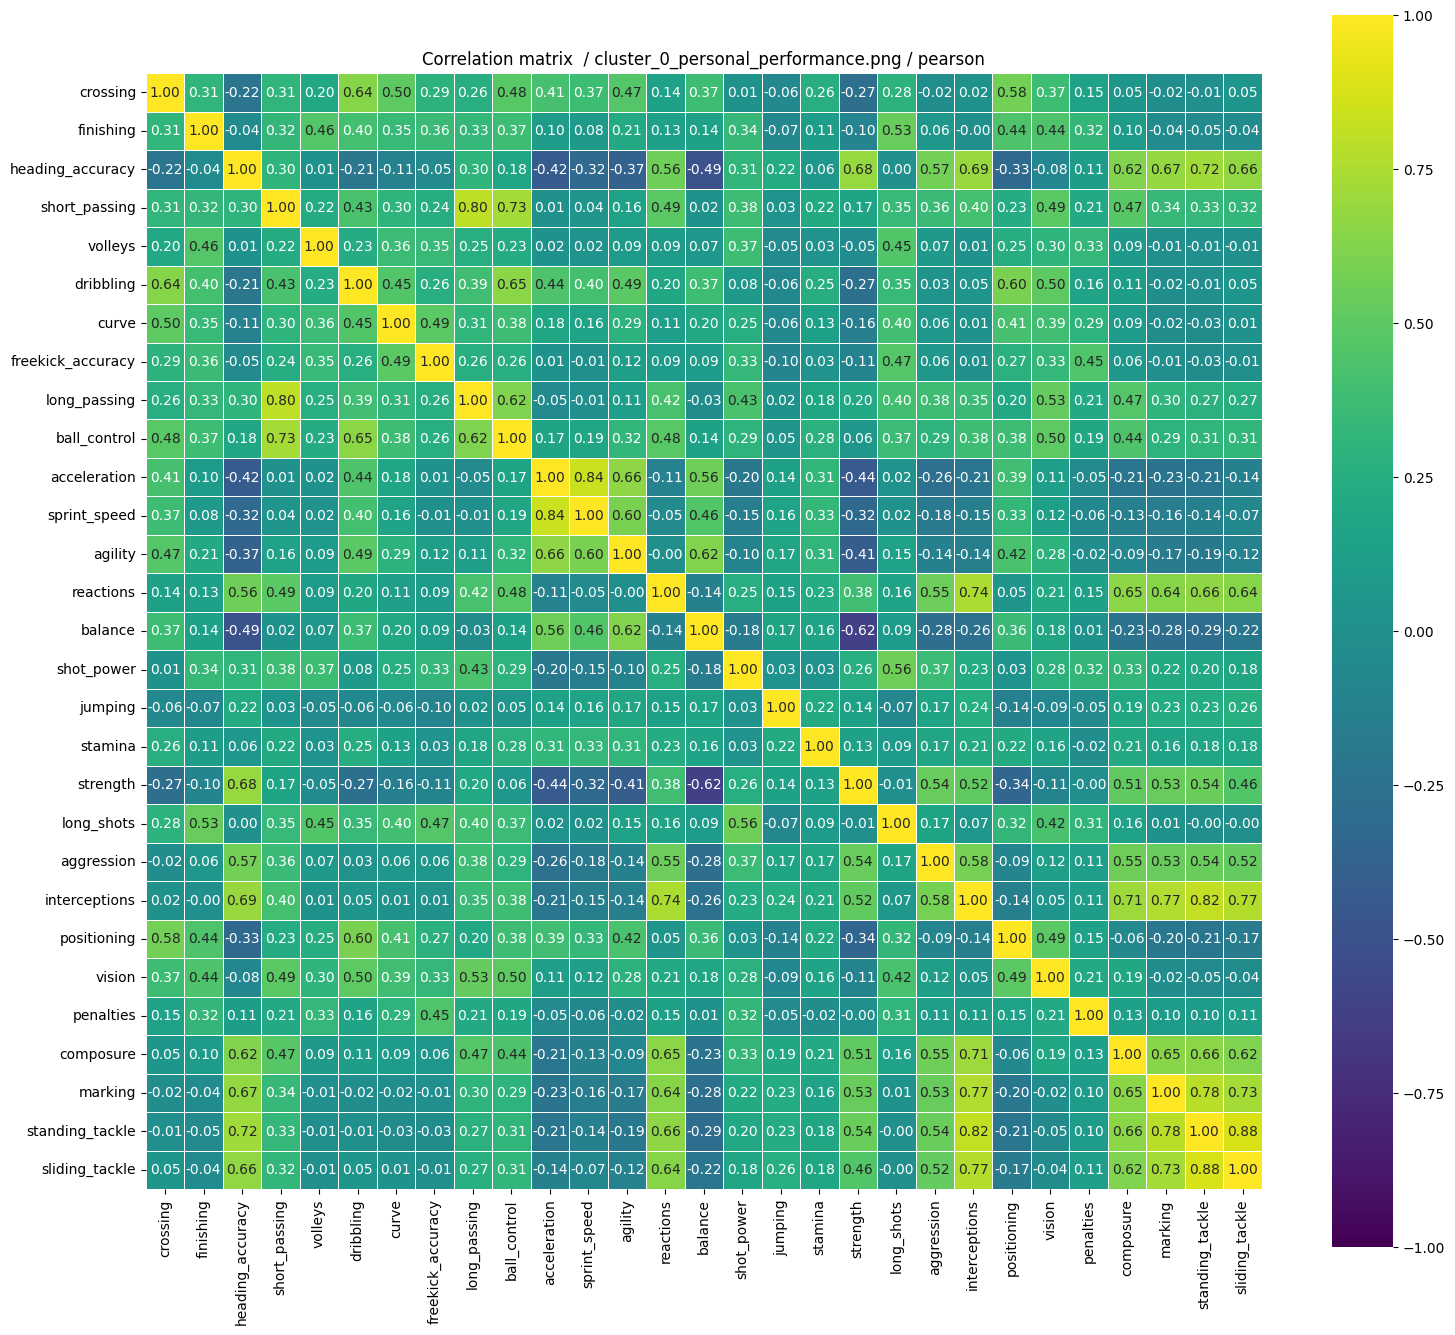

In [15]:
# Calculate the Pearson correlation matrix for the selected personal performance features.
# The cluster label column is removed because it is not an original performance feature.
correlation_matrix_pearson_cluster_0 = calculate_correlation_matrix(
    cluster_0.drop(columns=['pp_cluster']),
    'pearson'
)

# Visualize the Pearson correlation matrix as a heatmap.
# The figure will also be saved with the given file name.
show_correlation_matrix(
    correlation_matrix_pearson_cluster_0,
    corr_method='pearson',
    figure_name='cluster_0_personal_performance.png',
    save_dir='../../reports/figures'
)

## Analysis of Cluster 0 – Personal Performance Features

Cluster 0 shows players with strong relationships between **technical ability, passing, ball control, and defensive attributes**.

### Main Correlation Patterns

The strongest positive correlations are observed between:

- **standing_tackle and sliding_tackle**
  Players who are good at standing tackles are usually also good at sliding tackles.

- **marking, standing_tackle, sliding_tackle, and interceptions**
  These features are strongly connected and describe a clear **defensive player profile**.

- **ball_control, short_passing, long_passing, and vision**
  This suggests that players with better ball control usually also have stronger passing ability and better game vision.

- **dribbling, ball_control, and crossing**
  These features are typical for technically skilled players, especially wide players or attacking midfielders.

### Negative or Weak Relationships

Some physical or defensive attributes show weaker or negative relationships with attacking/technical skills. For example, **strength** and some defensive features do not strongly correlate with dribbling, acceleration, or agility.

### Final Conclusion

Cluster 0 appears to contain players whose performance profile is split into two main groups:

1. **Technical/playmaking players** – strong in passing, vision, ball control, dribbling, and crossing.
2. **Defensive players** – strong in marking, interceptions, standing tackle, and sliding tackle.

Overall, this cluster is useful because it separates players based on whether their strengths are more related to **technical attacking play** or **defensive contribution**.

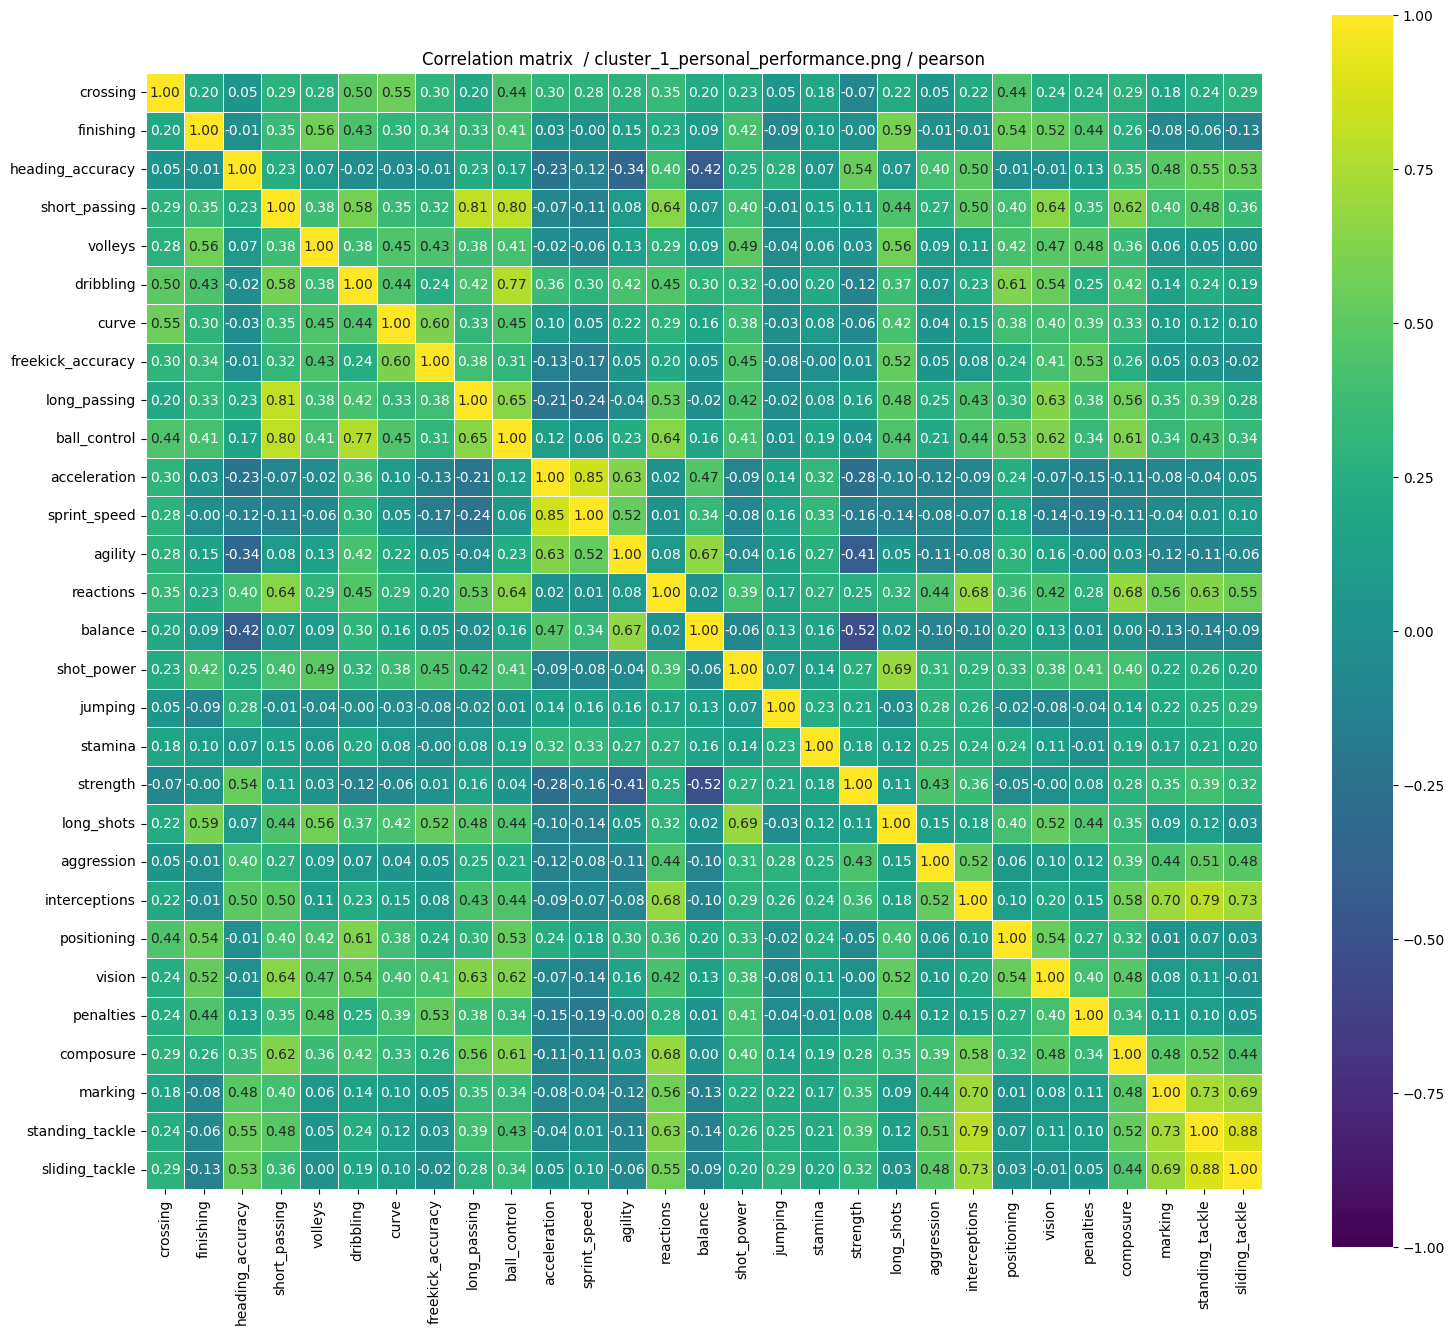

In [14]:
# Calculate the Pearson correlation matrix for the selected personal performance features.
# The cluster label column is removed because it is not an original performance feature.
correlation_matrix_pearson_cluster_1 = calculate_correlation_matrix(
    cluster_1.drop(columns=['pp_cluster']),
    'pearson'
)

# Visualize the Pearson correlation matrix as a heatmap.
# The figure will also be saved with the given file name.
show_correlation_matrix(
    correlation_matrix_pearson_cluster_1,
    corr_method='pearson',
    figure_name='cluster_1_personal_performance.png',
    save_dir='../../reports/figures'
)

## Analysis of Cluster 1 – Personal Performance Features

Cluster 1 shows stronger and more meaningful separation between **technical/playmaking attributes**, **defensive attributes**, and **physical speed attributes**.

### Main Correlation Patterns

The strongest positive correlations are observed between:

- **standing_tackle and sliding_tackle**
  This is the strongest relationship in the cluster. Players who are good at standing tackles are usually also good at sliding tackles.

- **marking, interceptions, standing_tackle, and sliding_tackle**
  These attributes form a clear defensive group. This suggests that Cluster 1 contains players with strong defensive contribution.

- **short_passing, long_passing, ball_control, and vision**
  These features are strongly connected. Players with good passing ability usually also have better ball control and better vision.

- **dribbling, ball_control, crossing, and curve**
  These features describe technically strong players who are more useful in attacking or creative roles.

- **acceleration and sprint_speed**
  These two physical attributes are strongly correlated, which means that players with high acceleration usually also have high sprint speed.

### Negative or Weaker Relationships

Some defensive features have weaker or negative relationships with attacking features such as **finishing**, **volleys**, and **dribbling**. This is expected because defensive players usually do not specialize in attacking actions.

Also, **strength** does not strongly correlate with speed-related features like **acceleration**, **sprint_speed**, and **agility**, meaning that physical power and speed describe different player profiles.

### Final Conclusion

Cluster 1 mainly separates players into three performance profiles:

1. **Defensive players** – strong in marking, interceptions, standing tackle, and sliding tackle.
2. **Technical/playmaking players** – strong in passing, ball control, vision, crossing, and dribbling.
3. **Fast players** – strong in acceleration and sprint speed.

Overall, Cluster 1 is useful because it clearly shows the difference between players with **defensive strength**, **technical creativity**, and **speed-based performance**.

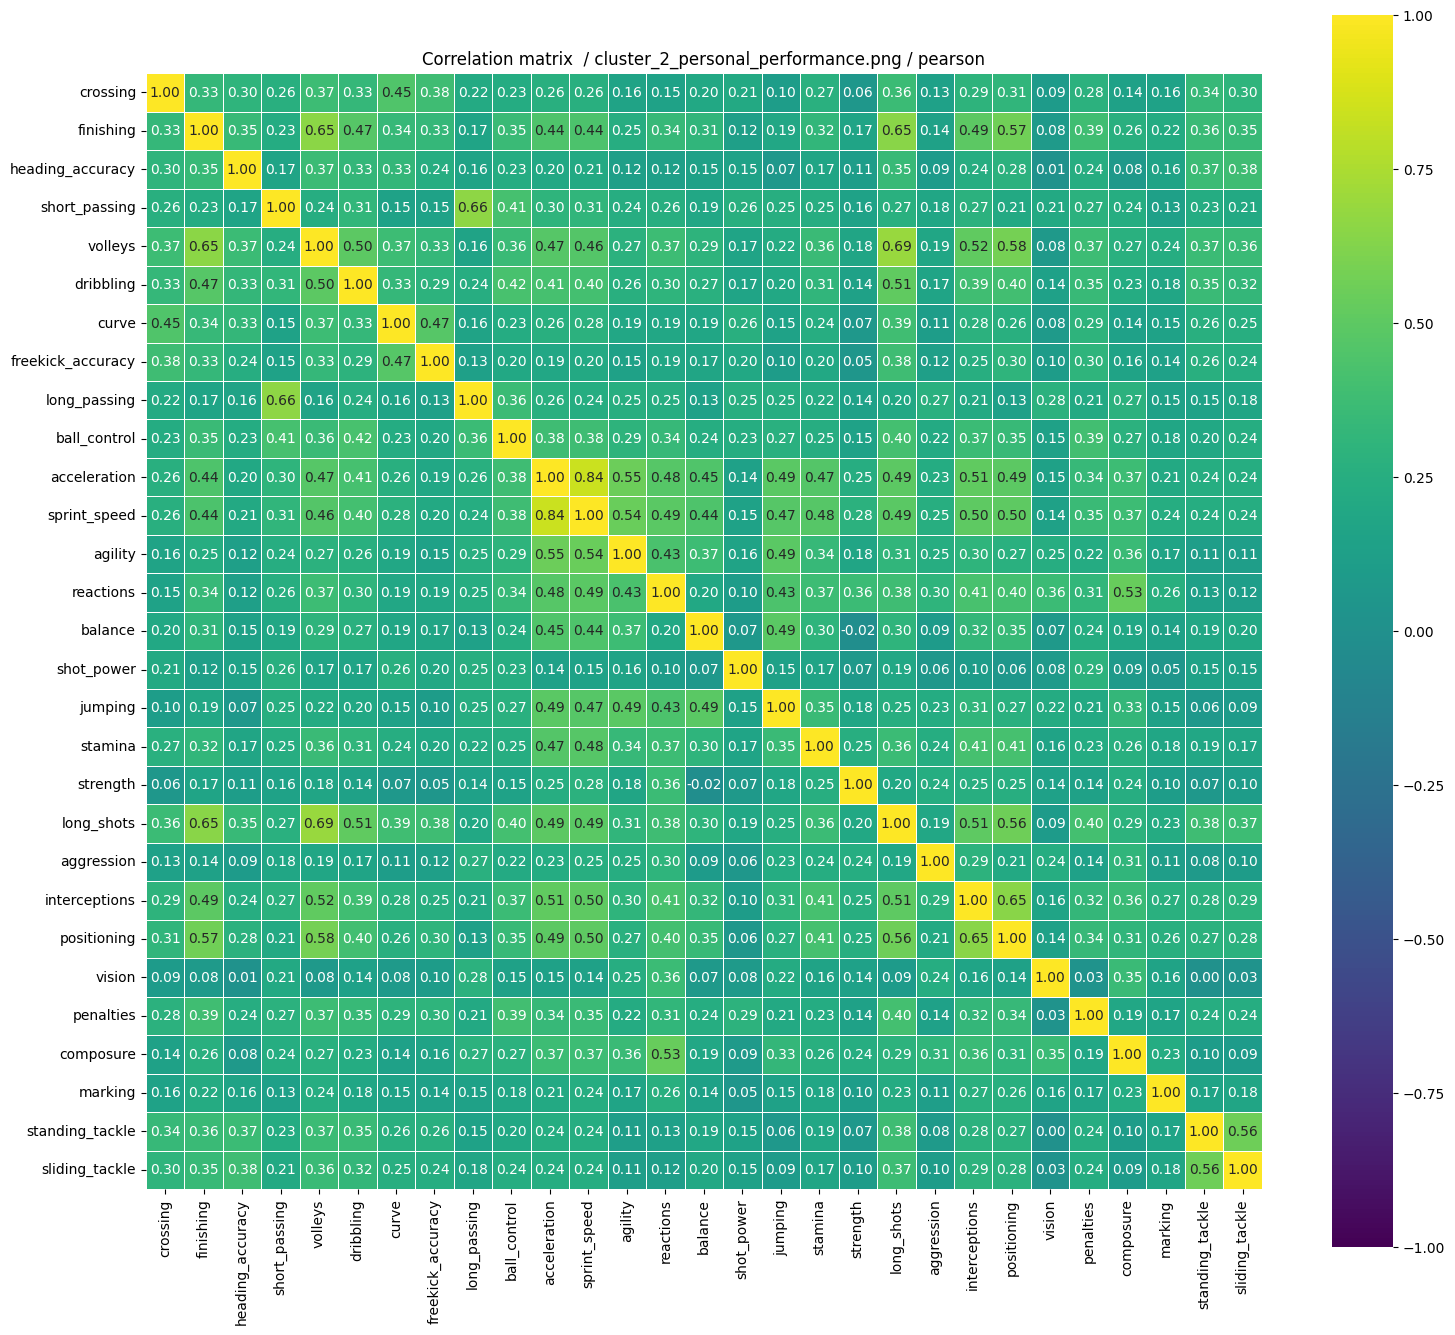

In [16]:
# Calculate the Pearson correlation matrix for the selected personal performance features.
# The cluster label column is removed because it is not an original performance feature.
correlation_matrix_pearson_cluster_2 = calculate_correlation_matrix(
    cluster_2.drop(columns=['pp_cluster']),
    'pearson'
)

# Visualize the Pearson correlation matrix as a heatmap.
# The figure will also be saved with the given file name.
show_correlation_matrix(
    correlation_matrix_pearson_cluster_2,
    corr_method='pearson',
    figure_name='cluster_2_personal_performance.png',
    save_dir='../../reports/figures'
)

## Analysis of Cluster 2 – Personal Performance Features

Cluster 2 shows a different structure compared to Cluster 1. The correlations are generally more balanced and less extreme, which suggests a more mixed player profile.

### Main Correlation Patterns

The strongest positive relationships are observed between:

- **finishing, volleys, long_shots, and positioning**
  These features describe an attacking profile. Players who are good at finishing are also usually better at shooting actions and attacking positioning.

- **acceleration, sprint_speed, and agility**
  These attributes form a clear physical-speed group. This means that fast players in this cluster usually also have good movement and agility.

- **standing_tackle and sliding_tackle**
  These two defensive actions are still positively correlated, but the relationship is weaker than in Cluster 1.

- **ball_control, short_passing, and long_passing**
  These features are connected, but not as strongly as in the previous cluster. This suggests that technical ability exists in the cluster, but it is not the dominant profile.

### Defensive Profile

The defensive features such as **marking, interceptions, standing_tackle, and sliding_tackle** are not as strongly connected as in Cluster 1. This means Cluster 2 is probably not mainly composed of strongly defensive players.

### Attacking Profile

The attacking attributes are more visible here. Features like **finishing, volleys, long_shots, positioning, and composure** show stronger relationships, which suggests that Cluster 2 contains more attacking-oriented players.

### Final Conclusion

Cluster 2 mainly represents players with a stronger **attacking and physical profile**.

The cluster appears to include players who rely more on:

1. **Shooting and attacking positioning**
2. **Speed and agility**
3. **General technical ability**

Overall, Cluster 2 is less defensive than Cluster 1 and seems more related to **offensive performance and movement-based attributes**.

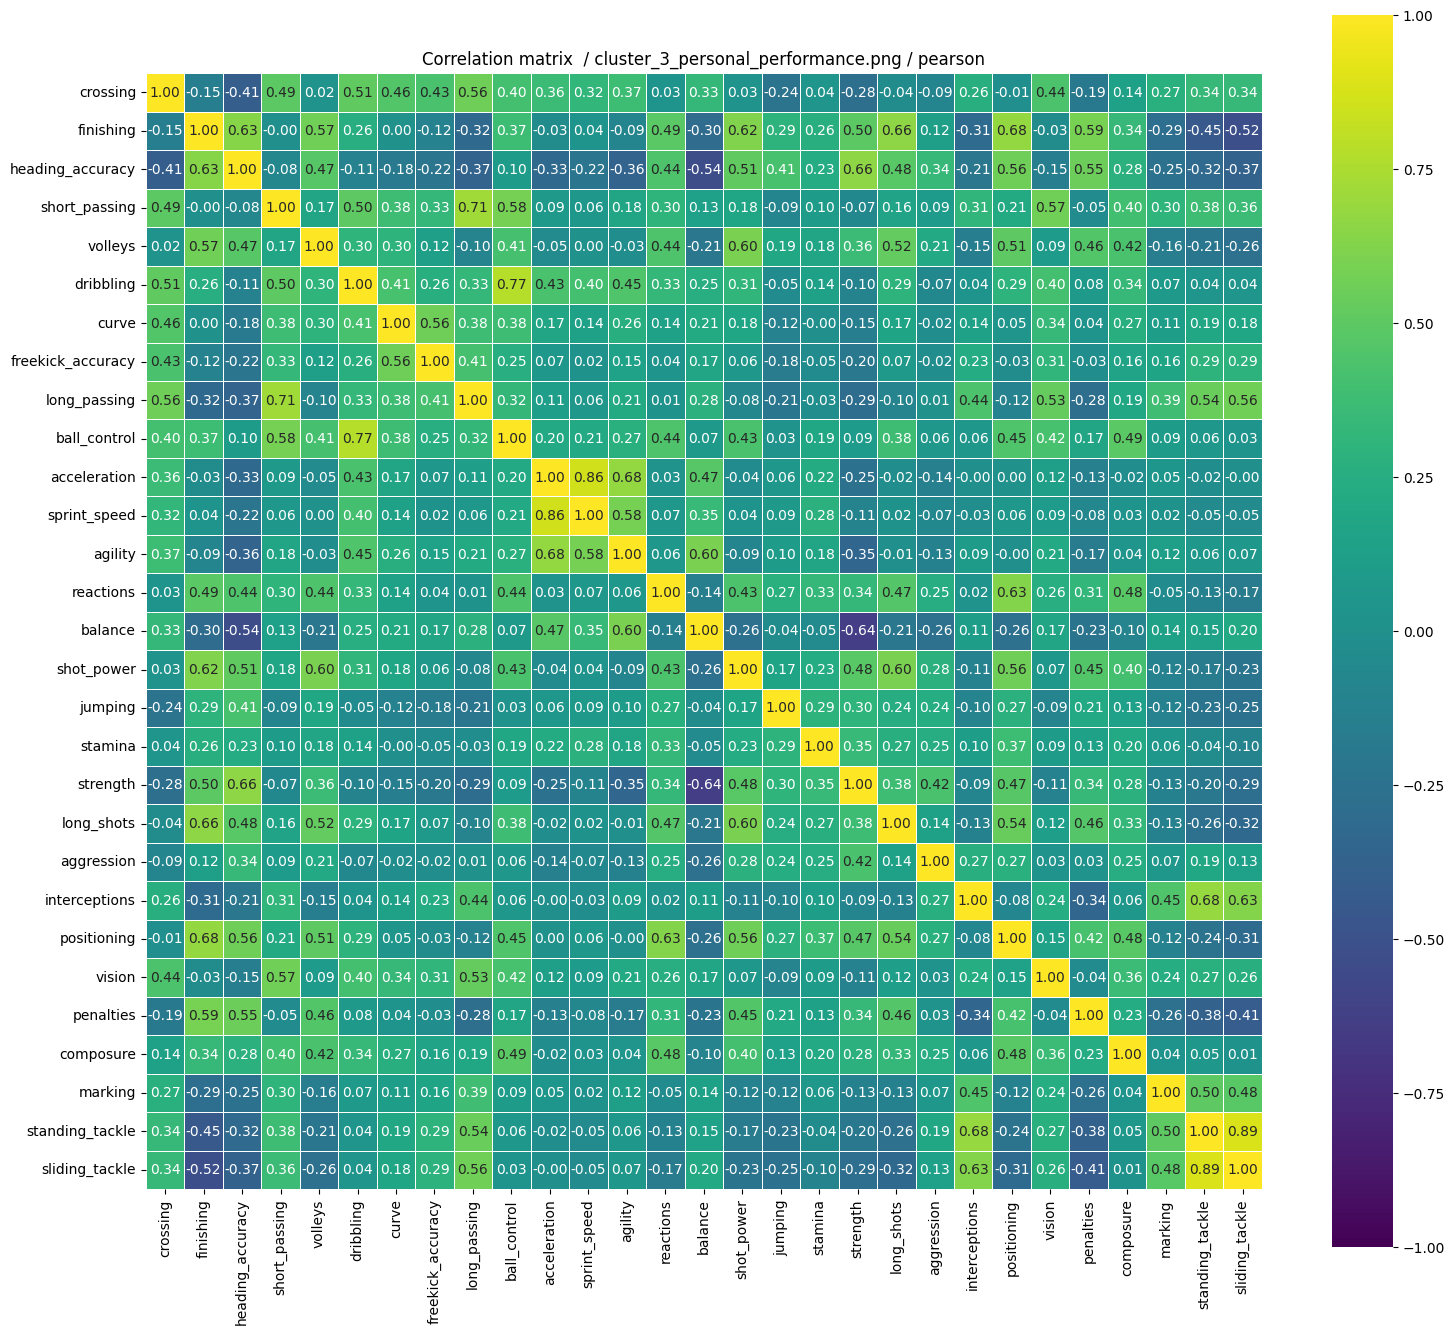

In [17]:
# Calculate the Pearson correlation matrix for the selected personal performance features.
# The cluster label column is removed because it is not an original performance feature.
correlation_matrix_pearson_cluster_3 = calculate_correlation_matrix(
    cluster_3.drop(columns=['pp_cluster']),
    'pearson'
)

# Visualize the Pearson correlation matrix as a heatmap.
# The figure will also be saved with the given file name.
show_correlation_matrix(
    correlation_matrix_pearson_cluster_3,
    corr_method='pearson',
    figure_name='cluster_3_personal_performance.png',
    save_dir='../../reports/figures'
)

## Analysis of Cluster 3 – Personal Performance Features

Cluster 3 shows a clearer split between **attacking/technical players**, **speed-based players**, and **defensive players**.

### Main Correlation Patterns

The strongest positive relationships are observed between:

- **standing_tackle and sliding_tackle**
  This is the strongest defensive relationship in the cluster. Players who are good at standing tackles are usually also good at sliding tackles.

- **interceptions, marking, standing_tackle, and sliding_tackle**
  These features form a defensive group, although the defensive block is not as dominant as in Cluster 1.

- **acceleration, sprint_speed, and agility**
  These attributes are strongly connected and describe fast, mobile players.

- **short_passing, long_passing, ball_control, and vision**
  These features describe technically skilled players who are comfortable in possession and passing.

- **finishing, positioning, long_shots, and shot_power**
  These features are connected with attacking contribution and shooting ability.

### Important Negative Relationships

There are some negative correlations between **defensive attributes** and some **attacking/technical attributes**. This suggests that players in this cluster are more clearly separated by role.

For example, players with stronger tackling and marking ability are less likely to be the strongest in finishing or attacking positioning.

### Final Conclusion

Cluster 3 appears to contain players with more specialized profiles:

1. **Defensive players** – strong in interceptions, marking, standing tackle, and sliding tackle.
2. **Fast players** – strong in acceleration, sprint speed, and agility.
3. **Attacking/technical players** – strong in finishing, positioning, ball control, passing, and vision.

Overall, Cluster 3 is useful because it shows stronger role-based separation between **defenders**, **fast wide players**, and **attacking/creative players**.

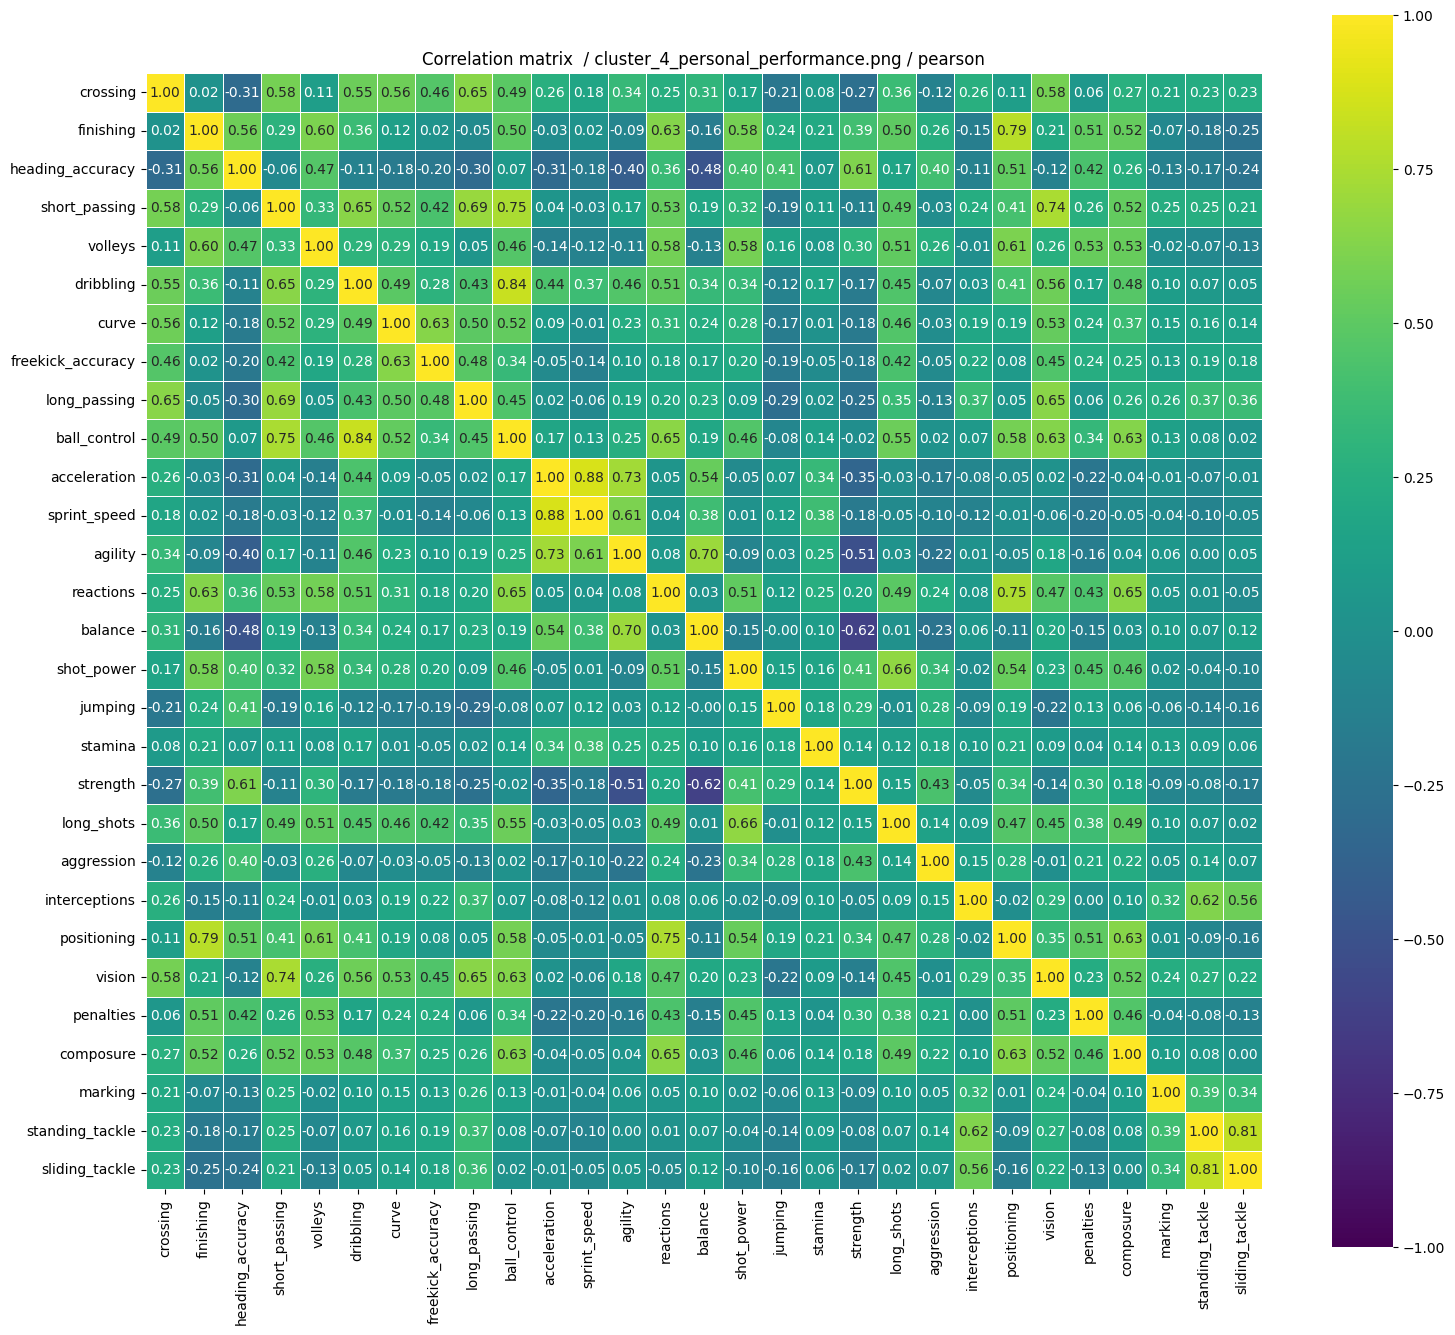

In [18]:
# Calculate the Pearson correlation matrix for the selected personal performance features.
# The cluster label column is removed because it is not an original performance feature.
correlation_matrix_pearson_cluster_4 = calculate_correlation_matrix(
    cluster_4.drop(columns=['pp_cluster']),
    'pearson'
)

# Visualize the Pearson correlation matrix as a heatmap.
# The figure will also be saved with the given file name.
show_correlation_matrix(
    correlation_matrix_pearson_cluster_4,
    corr_method='pearson',
    figure_name='cluster_4_personal_performance.png',
    save_dir='../../reports/figures'
)

## Analysis of Cluster 4 – Personal Performance Features

Cluster 4 shows strong relationships between **technical/playmaking attributes**, **attacking attributes**, and **speed-related attributes**. Compared to the previous clusters, the defensive profile is weaker and less dominant.

### Main Correlation Patterns

The strongest positive relationships are observed between:

- **acceleration, sprint_speed, and agility**
  These features are strongly connected and describe players with good speed, explosiveness, and movement ability.

- **short_passing, long_passing, ball_control, vision, and crossing**
  These attributes form a clear technical/playmaking group. Players with good ball control usually also have stronger passing and vision.

- **finishing, positioning, volleys, shot_power, and long_shots**
  These features are related to attacking performance. This suggests that Cluster 4 contains players who contribute more in offensive situations.

- **standing_tackle and sliding_tackle**
  These defensive actions are still positively correlated, but the defensive group is not as strong as in Cluster 1 or Cluster 3.

### Defensive Profile

Defensive attributes such as **marking, interceptions, standing_tackle, and sliding_tackle** are present, but they do not dominate the cluster. This suggests that Cluster 4 is not mainly composed of defensive players.

### Final Conclusion

Cluster 4 appears to represent players with a stronger **technical and attacking profile**.

The cluster mainly includes players who rely on:

1. **Ball control and passing**
2. **Speed and agility**
3. **Shooting and attacking positioning**

Overall, Cluster 4 is more related to **creative and attacking performance** than to defensive contribution.

## General Conclusion About the Clusters

The correlation matrices show that the players are separated mainly by **role-based performance profiles**.
Across all clusters, some relationships remain stable, but each cluster emphasizes different types of player characteristics.

The most consistent pattern is that **defensive attributes**, **technical/playmaking attributes**, **attacking attributes**, and **speed-related attributes** form separate groups.

### Main Overall Findings

- **Defensive features** such as `marking`, `interceptions`, `standing_tackle`, and `sliding_tackle` are strongly connected in most clusters.
- **Technical features** such as `ball_control`, `short_passing`, `long_passing`, `vision`, and `dribbling` often move together.
- **Attacking features** such as `finishing`, `positioning`, `volleys`, `long_shots`, and `shot_power` are more visible in attacking-oriented clusters.
- **Physical speed features** such as `acceleration`, `sprint_speed`, and `agility` form a clear group in several clusters.
- The strongest repeated correlation is usually between **standing_tackle** and **sliding_tackle**, which confirms that tackling skills are strongly related.

---

## Summary DataFrame: Main Characteristics of Each Cluster

| Cluster | Main Profile | Strong Feature Groups | Defensive Strength | Technical Strength | Attacking Strength | Speed / Physical Strength | General Interpretation |
|---|---|---|---|---|---|---|---|
| Cluster 0 | Mixed technical and defensive profile | Passing, ball control, tackles, interceptions | High | High | Medium | Medium | Contains both technical/playmaking players and defensive players. |
| Cluster 1 | Strong defensive and technical separation | Tackling, marking, interceptions, passing, ball control | Very High | High | Medium | Medium | Best cluster for identifying clear defensive players and playmakers. |
| Cluster 2 | Attacking and physical profile | Finishing, volleys, long shots, positioning, acceleration, sprint speed | Medium / Low | Medium | High | High | More related to offensive players with good movement and shooting ability. |
| Cluster 3 | Role-specialized profile | Defensive block, speed block, attacking/technical block | High | High | High | High | Shows strong separation between defenders, fast players, and attackers. |
| Cluster 4 | Creative and attacking profile | Ball control, passing, vision, finishing, positioning, speed | Low / Medium | Very High | High | High | More related to creative, attacking, and technically strong players. |

---

## Final Interpretation

Overall, the clustering separates players into different football profiles:

1. **Defensive-oriented players**
   Players with strong `marking`, `interceptions`, `standing_tackle`, and `sliding_tackle`.

2. **Technical/playmaking players**
   Players with strong `ball_control`, `short_passing`, `long_passing`, `vision`, and `dribbling`.

3. **Attacking players**
   Players with strong `finishing`, `positioning`, `volleys`, `long_shots`, and `shot_power`.

4. **Speed-based players**
   Players with strong `acceleration`, `sprint_speed`, and `agility`.

The most useful clusters for interpretation are **Cluster 1, Cluster 3, and Cluster 4**, because they show clearer role-based patterns.
Cluster 2 is more attacking and physical, while Cluster 0 is more mixed.